In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naveenkumar2529","key":"c75d3dcf1b5df2ac2a31f21626b66217"}'}

In [3]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

In [4]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:09<00:00, 18.5MB/s]



In [6]:
import zipfile

with zipfile.ZipFile("face-mask-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("face_mask_dataset")

In [7]:
import os

os.listdir("face_mask_dataset")

['data']

In [8]:
base_path = "face_mask_dataset"

for root, dirs, files in os.walk(base_path):
    print(root)

face_mask_dataset
face_mask_dataset/data
face_mask_dataset/data/with_mask
face_mask_dataset/data/without_mask


In [9]:
data_path = "/content/face_mask_dataset/data"

print(os.listdir(data_path))
# Output:
# ['with_mask', 'without_mask']

['with_mask', 'without_mask']


In [12]:
!pip install split-folders

In [13]:
import splitfolders

input_folder = "/content/face_mask_dataset/data"
output_folder = "/content/face_mask_dataset"

splitfolders.ratio(
    input=input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 7553 files [00:03, 2297.08 files/s]


In [14]:
import os

train_path = "/content/face_mask_dataset/train"
val_path   = "/content/face_mask_dataset/val"
test_path  = "/content/face_mask_dataset/test"

In [15]:
for folder in os.listdir(train_path):
    path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(path)))

with_mask : 2607
without_mask : 2679


In [16]:
data_path = "/content/face_mask_dataset/data"

In [17]:
for folder in os.listdir(train_path):

    path = os.path.join(train_path, folder)

    print(folder, ":", len(os.listdir(path)))

with_mask : 2607
without_mask : 2679


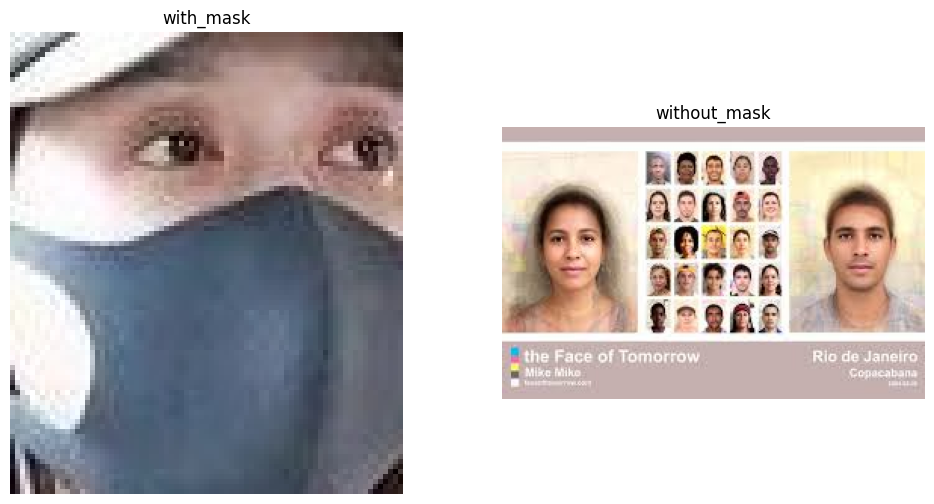

In [18]:
import matplotlib.pyplot as plt
import cv2

classes = os.listdir(train_path)

plt.figure(figsize=(12,6))

for i, category in enumerate(classes):

    img_name = os.listdir(os.path.join(train_path, category))[0]

    img_path = os.path.join(train_path, category, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

In [19]:
for category in classes:

    img_name = os.listdir(os.path.join(train_path, category))[0]

    img_path = os.path.join(train_path, category, img_name)

    img = cv2.imread(img_path)

    print(category, "Shape :", img.shape)

with_mask Shape : (93, 79, 3)
without_mask Shape : (180, 280, 3)


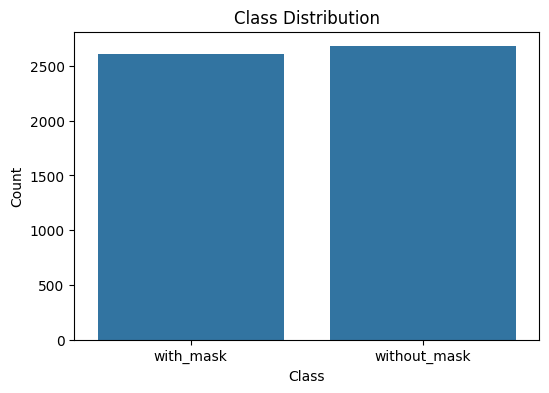

In [20]:
import seaborn as sns
import pandas as pd

class_names = []
image_counts = []

for category in classes:

    path = os.path.join(train_path, category)

    class_names.append(category)
    image_counts.append(len(os.listdir(path)))

df = pd.DataFrame({
    "Class": class_names,
    "Count": image_counts
})

plt.figure(figsize=(6,4))

sns.barplot(x="Class", y="Count", data=df)

plt.title("Class Distribution")
plt.show()

In [21]:
from PIL import Image

corrupt = 0

for category in classes:

    folder_path = os.path.join(train_path, category)

    for file in os.listdir(folder_path):

        try:
            img = Image.open(os.path.join(folder_path, file))
            img.verify()

        except:
            corrupt += 1

print("Corrupted Images :", corrupt)

Corrupted Images : 0


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [23]:
import warnings

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_ds = val_gen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5286 images belonging to 2 classes.
Found 1132 images belonging to 2 classes.


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Train generator with augmentation
train_gen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='nearest'
)

# Validation generator
val_gen_aug = ImageDataGenerator(rescale=1./255)

# Augmented Train Dataset
train_ds_aug = train_gen_aug.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

# Validation Dataset
val_ds_aug = val_gen_aug.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5286 images belonging to 2 classes.
Found 1132 images belonging to 2 classes.


In [26]:
import warnings

warnings.filterwarnings("ignore")

In [27]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

In [28]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [29]:
history=model.fit(train_ds,epochs=50,validation_data=val_ds)

Epoch 1/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - accuracy: 0.8352 - loss: 0.3839 - val_accuracy: 0.9011 - val_loss: 0.2384
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.9001 - loss: 0.2390 - val_accuracy: 0.9099 - val_loss: 0.2129
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.9187 - loss: 0.1983 - val_accuracy: 0.9046 - val_loss: 0.2638
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.9429 - loss: 0.1428 - val_accuracy: 0.9019 - val_loss: 0.2711
Epoch 5/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.9510 - loss: 0.1212 - val_accuracy: 0.9196 - val_loss: 0.2611
Epoch 6/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.9644 - loss: 0.0869 - val_accuracy: 0.9178 - val_loss: 0.2707
Epoch 7/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.9767 - loss: 0.0686 - val_accuracy: 0.9187 - val_loss: 0.3224
Epoch 8/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.9781 - loss: 0.0622 -

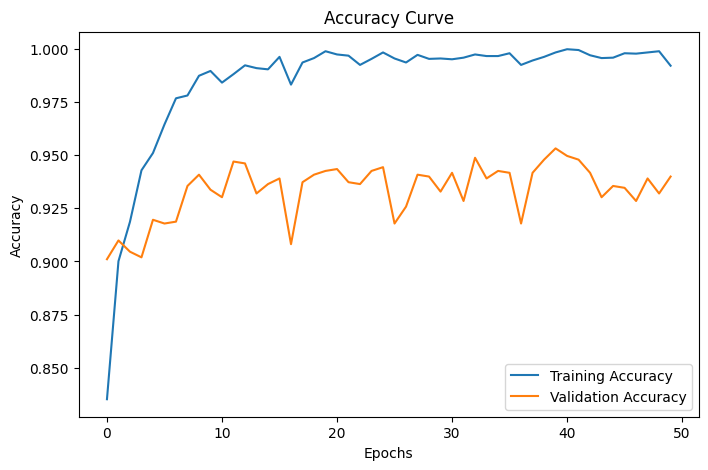

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [31]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Model
train_loss, train_accuracy = model.evaluate(train_ds)

test_loss, test_accuracy = model.evaluate(val_ds)

# Predict on Validation Data
val_ds.reset()

test_pred = model.predict(val_ds)

# Convert Probability into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# Actual Labels
y_test_actual = val_ds.classes

# Precision, Recall, F1 Score
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# Check Overfitting / Underfitting
diff = train_accuracy - test_accuracy

if diff > 0.10:
    status = "Overfitting"

elif diff < -0.05:
    status = "Underfitting"

else:
    status = "Good Fit"

# Create Result DataFrame
result_cnn = pd.DataFrame({

    "Model": ["Simple CNN"],

    "Train Accuracy": [round(train_accuracy, 4)],

    "Test Accuracy": [round(test_accuracy, 4)],

    "Precision": [round(precision, 4)],

    "Recall": [round(recall, 4)],

    "F1 Score": [round(f1, 4)],

    "Status": [status]

})

# Display Result
result_cnn

166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9996 - loss: 5.6107e-04
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9399 - loss: 0.6907
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Status
0,Simple CNN,0.9996,0.9399,0.9617,0.9181,0.9394,Good Fit


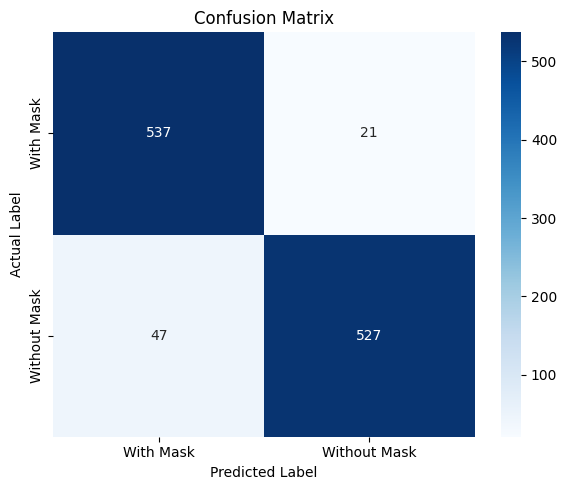

              precision    recall  f1-score   support

   With Mask       0.92      0.96      0.94       558
Without Mask       0.96      0.92      0.94       574

    accuracy                           0.94      1132
   macro avg       0.94      0.94      0.94      1132
weighted avg       0.94      0.94      0.94      1132



In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted probabilities into class labels
test_pred = (test_pred > 0.5).astype(int).ravel()

# Convert actual labels into 1D format
y_test_actual = np.array(y_test_actual).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_test_actual, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Classification Report
print(
    classification_report(
        y_test_actual,
        test_pred,
        target_names=["With Mask", "Without Mask"]
    )
)

In [37]:
# Save Model
model.save("CNN_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [38]:
from google.colab import files

# Download CNN model
files.download("CNN_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
model.save("CNN_model.h5")

In [40]:
from google.colab import files

# Download CNN model
files.download("CNN_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9983 - loss: 0.0037
Epoch 1: val_loss improved from None to 0.62789, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.9985 - loss: 0.0033 - val_accuracy: 0.9408 - val_loss: 0.6279
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9979 - loss: 0.0113
Epoch 2: val_loss did not improve from 0.62789
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.9977 - loss: 0.0081 - val_accuracy: 0.9276 - val_loss: 0.6818
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9980 - loss: 0.0064
Epoch 3: val_loss did not improve from 0.62789
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.9977 - loss: 0.0056 - val_accuracy: 0.9443 - val_loss: 0.8386
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 4: val_loss did not improve from 0.62789
166/166 ━━━━

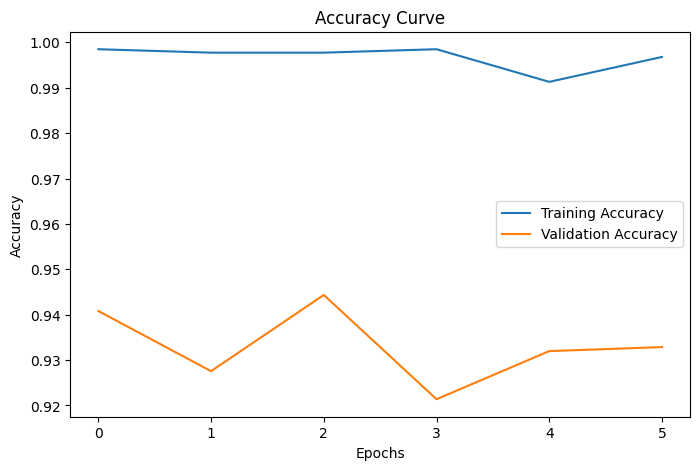

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [43]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Model
train_loss, train_accuracy = model.evaluate(train_ds)

test_loss, test_accuracy = model.evaluate(val_ds)

# Predict on Validation Data
val_ds.reset()

test_pred = model.predict(val_ds)

# Convert Probability into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# Actual Labels
y_test_actual = val_ds.classes

# Precision, Recall, F1 Score
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# Check Overfitting / Underfitting
diff = train_accuracy - test_accuracy

if diff > 0.10:
    status = "Overfitting"

elif diff < -0.05:
    status = "Underfitting"

else:
    status = "Good Fit"

# Create Result DataFrame
result_cnn_early = pd.DataFrame({

    "Model": ["Simple CNN with Early Stopping"],

    "Train Accuracy": [round(train_accuracy, 4)],

    "Test Accuracy": [round(test_accuracy, 4)],

    "Precision": [round(precision, 4)],

    "Recall": [round(recall, 4)],

    "F1 Score": [round(f1, 4)],

    "Status": [status]

})

# Display Result
result_cnn_early

166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9998 - loss: 6.3787e-04
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9408 - loss: 0.6279
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Status
0,Simple CNN with Early Stopping,0.9998,0.9408,0.9487,0.9338,0.9412,Good Fit


In [ ]:
model.save("CNN_model_early.keras")

print("Model Saved Successfully!")

In [ ]:
# Download CNN model
files.download("CNN_model_early.keras")

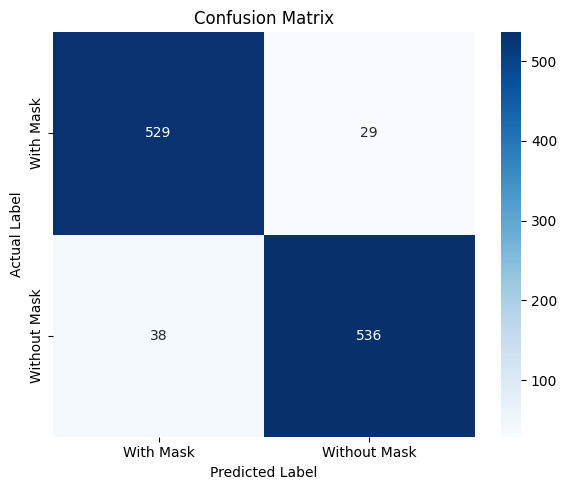

              precision    recall  f1-score   support

   With Mask       0.93      0.95      0.94       558
Without Mask       0.95      0.93      0.94       574

    accuracy                           0.94      1132
   macro avg       0.94      0.94      0.94      1132
weighted avg       0.94      0.94      0.94      1132



In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted probabilities into class labels
test_pred = (test_pred > 0.5).astype(int).ravel()

# Convert actual labels into 1D format
y_test_actual = np.array(y_test_actual).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_test_actual, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Classification Report
print(
    classification_report(
        y_test_actual,
        test_pred,
        target_names=["With Mask", "Without Mask"]
    )
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load VGG16 base model
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze VGG16 layers
vgg_base.trainable = False

# Build model
model_vgg16 = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# Compile model
model_vgg16.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg16_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Train model
history_vgg16 = model_vgg16.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Model
train_loss, train_accuracy = model_vgg16.evaluate(train_ds)

test_loss, test_accuracy = model_vgg16.evaluate(val_ds)

# Predict on Validation Data
val_ds.reset()

test_pred = model_vgg16.predict(val_ds)

# Convert Probability into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# Actual Labels
y_test_actual = val_ds.classes

# Precision, Recall, F1 Score
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# Check Overfitting / Underfitting
diff = train_accuracy - test_accuracy

if diff > 0.10:
    status = "Overfitting"

elif diff < -0.05:
    status = "Underfitting"

else:
    status = "Good Fit"

# Create Result DataFrame
result_model_vgg16 = pd.DataFrame({

    "Model": ["VGG16"],

    "Train Accuracy": [round(train_accuracy, 4)],

    "Test Accuracy": [round(test_accuracy, 4)],

    "Precision": [round(precision, 4)],

    "Recall": [round(recall, 4)],

    "F1 Score": [round(f1, 4)],

    "Status": [status]

})

# Display Result
result_model_vgg16

In [ ]:
model_vgg16.save("model_vgg16.keras")

print("Model Saved Successfully!")

In [ ]:
# Download CNN model
files.download("model_vgg16.keras")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted probabilities into class labels
test_pred = (test_pred > 0.5).astype(int).ravel()

# Convert actual labels into 1D format
y_test_actual = np.array(y_test_actual).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_test_actual, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Classification Report
print(
    classification_report(
        y_test_actual,
        test_pred,
        target_names=["With Mask", "Without Mask"]
    )
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load VGG16 base model
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze VGG16 layers
vgg_base.trainable = False

# Build model
model_vgg16_aug = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# Compile model
model_vgg16_aug.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg16_model_aug.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Train model
history_vgg16_aug = model_vgg16_aug.fit(
    train_ds_aug,
    epochs=50,
    validation_data=val_ds_aug,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_vgg16_aug.history["accuracy"], label="Training Accuracy")

plt.plot(history_vgg16_aug.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Model
train_loss, train_accuracy = model_vgg16_aug.evaluate(train_ds_aug)

test_loss, test_accuracy = model_vgg16_aug.evaluate(val_ds_aug)

# Predict on Validation Data
val_ds_aug.reset()

test_pred = model_vgg16_aug.predict(val_ds_aug)

# Convert Probability into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# Actual Labels
y_test_actual = val_ds_aug.classes

# Precision, Recall, F1 Score
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# Check Overfitting / Underfitting
diff = train_accuracy - test_accuracy

if diff > 0.10:
    status = "Overfitting"

elif diff < -0.05:
    status = "Underfitting"

else:
    status = "Good Fit"

# Create Result DataFrame
result_model_vgg16_aug = pd.DataFrame({

    "Model": ["VGG16 with Data Augmentation"],

    "Train Accuracy": [round(train_accuracy, 4)],

    "Test Accuracy": [round(test_accuracy, 4)],

    "Precision": [round(precision, 4)],

    "Recall": [round(recall, 4)],

    "F1 Score": [round(f1, 4)],

    "Status": [status]

})

# Display Result
result_model_vgg16_aug

In [ ]:
model_vgg16.save("model_vgg16_aug.keras")

print("Model Saved Successfully!")

In [ ]:
# Download CNN model
files.download("model_vgg16_aug.keras")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted probabilities into class labels
test_pred = (test_pred > 0.5).astype(int).ravel()

# Convert actual labels into 1D format
y_test_actual = np.array(y_test_actual).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_test_actual, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Classification Report
print(
    classification_report(
        y_test_actual,
        test_pred,
        target_names=["With Mask", "Without Mask"]
    )
)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# Load VGG16 base model
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# Fine Tuning with Data Augmentation

vgg_base.trainable = True

# Freeze all layers except last 4 layers
for layer in vgg_base.layers[:-4]:
    layer.trainable = False

# Build model
model_vgg16_aug_tune = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])


# Compile with low learning rate
model_vgg16_aug_tune.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg16_finetune_data_aug.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Train Fine Tuning Model
history_vgg16_finetune_aug = model_vgg16_aug_tune.fit(
    train_ds_aug,
    epochs=50,
    validation_data=val_ds_aug,
    callbacks=[early_stop, checkpoint]
)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_vgg16_finetune_aug.history["accuracy"], label="Training Accuracy")

plt.plot(history_vgg16_finetune_aug.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Model
train_loss, train_accuracy = model_vgg16_aug_tune.evaluate(train_ds_aug)
test_loss, test_accuracy = model_vgg16_aug_tune.evaluate(val_ds_aug)

# Predict on Validation Data
val_ds_aug.reset()
test_pred = model_vgg16_aug_tune.predict(val_ds_aug)

# Convert probabilities into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# Actual Labels using classes
y_test_actual = val_ds_aug.classes

# Metrics
precision = precision_score(y_test_actual, test_pred)
recall = recall_score(y_test_actual, test_pred)
f1 = f1_score(y_test_actual, test_pred)

# Check Model Status
diff = train_accuracy - test_accuracy

if diff > 0.10:
    status = "Overfitting"
elif diff < -0.05:
    status = "Underfitting"
else:
    status = "Good Fit"

# Create Result DataFrame
result_vgg16_aug_tune = pd.DataFrame({
    "Model": ["VGG16 + Data Augmentation + Fine Tuning"],
    "Train Accuracy": [round(train_accuracy, 4)],
    "Test Accuracy": [round(test_accuracy, 4)],
    "Precision": [round(precision, 4)],
    "Recall": [round(recall, 4)],
    "F1 Score": [round(f1, 4)],
    "Status": [status]
})

# Display Result
result_vgg16_aug_tune

In [ ]:
model_vgg16_aug.save("model_vgg16_aug_fine_tunning.keras")
print("model_vgg16_aug saved Successfully")

In [ ]:
# Download CNN model
files.download("model_vgg16_aug_fine_tunning.keras")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted probabilities into class labels
test_pred = (test_pred > 0.5).astype(int).ravel()

# Convert actual labels into 1D format
y_test_actual = np.array(y_test_actual).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_test_actual, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Classification Report
print(
    classification_report(
        y_test_actual,
        test_pred,
        target_names=["With Mask", "Without Mask"]
    )
)

In [ ]:
# Combine All Result DataFrames

df_final = pd.concat([
    result_cnn,
    result_cnn_early,
    result_model_vgg16,
    result_model_vgg16_aug,
    result_vgg16_aug_tune
], ignore_index=True)

# Display Final DataFrame
df_final

In [ ]:
df_final.sort_values(by="Test Accuracy", ascending=False)